# Task I: Multi-Sector Energy Optimization (Electricity + Heating)

## Objective
Co-optimize electricity and heating sectors to minimize total system cost while meeting demand constraints across both sectors. This notebook extends Task D by integrating heating demand and heat production technologies (heat pumps, boilers, thermal storage) with the electricity system.

### Key Features:
- **Electricity sector**: Generation, transmission (interconnectors), storage
- **Heating sector**: Heat production (heat pumps, boilers), thermal storage, district heating
- **Cross-sector coupling**: Electricity-to-heat conversion via heat pumps
- **Co-optimization**: Unified cost minimization across both sectors

In [9]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tempfile
from pathlib import Path

# ==========================================
# 0. Environment and Path Configuration
# ==========================================
script_dir = os.getcwd()
os.chdir(script_dir)

# Use a temp directory to avoid permission issues
safe_temp_dir = os.path.join(script_dir, "temp")

if not os.path.exists(safe_temp_dir):
    os.makedirs(safe_temp_dir)

os.environ['TMPDIR'] = safe_temp_dir
os.environ['TEMP'] = safe_temp_dir
os.environ['TMP'] = safe_temp_dir
tempfile.tempdir = safe_temp_dir

print(f"Working directory: {script_dir}")
print("Environment setup complete.")

Working directory: c:\Users\Tessa Bruggeling\OneDrive - Danmarks Tekniske Universitet\master courses\Year 2\Integrated Energy Grids\Task I\Part D
Environment setup complete.


In [10]:
# ==========================================
# 1. Initialize Network with Electricity and Heating Sectors
# ==========================================
n = pypsa.Network()

# Hourly snapshots for a full year (8760 hours)
snapshots = pd.date_range("2017-01-01 00:00", "2017-12-31 23:00", freq="h")
n.set_snapshots(snapshots)

countries = ["DE", "FR", "AT", "CH"]

# ========== Electricity Sector ==========
# Add electricity buses (400 kV)
for c in countries:
    n.add("Bus", f"{c}", v_nom=400, carrier="AC")

# ========== Heating Sector ==========
# Add heating buses (district heating, typically 80-100°C)
for c in countries:
    n.add("Bus", f"{c}_heat", carrier="heat")

print(f"✅ Created {len(countries)} electricity buses and {len(countries)} heating buses")
print(f"Total buses: {len(n.buses)}")

# ==========================================
# 2. Add Interconnectors (HVAC Lines) - Electricity Only
# ==========================================
interconnectors = {
    "AT-CH": {"bus0": "AT", "bus1": "CH", "s_nom": 2152.75},
    "AT-DE": {"bus0": "AT", "bus1": "DE", "s_nom": 4232.10},
    "CH-DE": {"bus0": "CH", "bus1": "DE", "s_nom": 7106.32},
    "CH-FR": {"bus0": "CH", "bus1": "FR", "s_nom": 2926.94},
    "DE-FR": {"bus0": "DE", "bus1": "FR", "s_nom": 4120.00}
}

for name, params in interconnectors.items():
    n.add("Line", name,
          bus0=params["bus0"],
          bus1=params["bus1"],
          s_nom=params["s_nom"],
          s_nom_extendable=False,
          x=0.1)

print(f"✅ Added {len(interconnectors)} electricity interconnectors")

✅ Created 4 electricity buses and 4 heating buses
Total buses: 8
✅ Added 5 electricity interconnectors


In [11]:
# ==========================================
# 3. Define Technology Parameters
# ==========================================

# ========== ELECTRICITY SECTOR TECHNOLOGIES ==========
electricity_costs = {
    "Wind Onshore": {"capital_cost": 103363.0, "marginal_cost": 0.01},
    "Solar": {"capital_cost": 49219.0, "marginal_cost": 0.01},
    "Fossil Gas": {"capital_cost": 66534.0, "marginal_cost": 55.38},      
    "Hydro Run-of-river and pondage": {"capital_cost": 270930.0, "marginal_cost": 0.01},
    "Hydro Water Reservoir": {"capital_cost": 160620.0, "marginal_cost": 0.01},
    "Fossil Hard coal": {"capital_cost": 135000.0, "marginal_cost": 40.0},
    "Nuclear": {"capital_cost": 450000.0, "marginal_cost": 12.0},
    "Hydro Pumped Storage": {"capital_cost": 160000.0, "marginal_cost": 2.0}
}

electricity_by_country = {
    "DE": ["Wind Onshore", "Solar", "Fossil Hard coal", "Fossil Gas"], 
    "FR": ["Wind Onshore", "Solar", "Fossil Gas", "Nuclear"],
    "CH": ["Wind Onshore", "Solar", "Hydro Run-of-river and pondage", "Hydro Water Reservoir", "Hydro Pumped Storage"],
    "AT": ["Wind Onshore", "Solar", "Fossil Gas", "Hydro Run-of-river and pondage", "Hydro Water Reservoir", "Hydro Pumped Storage"]
}

# Variable Renewable Energy Sources (VRES) requiring p_max_pu profiles
vres_techs = ["Wind Onshore", "Solar", "Hydro Run-of-river and pondage"]

# heat pump only
heating_costs = {
    "Heat Pump": {
        "capital_cost": 1050.0,   # EUR/kWth
        "marginal_cost": 0.0,     # can also use 0.5 if you want a tiny variable O&M
        "efficiency": 3.0         # COP
    }
}

heating_by_country = {
    "DE": ["Heat Pump"],
    "FR": ["Heat Pump"],
    "CH": ["Heat Pump"],
    "AT": ["Heat Pump"]
}
print("✅ Technology parameters defined:")
print(f"  - Electricity technologies: {len(electricity_costs)}")
print(f"  - Heating technologies: {len(heating_costs)}")

✅ Technology parameters defined:
  - Electricity technologies: 8
  - Heating technologies: 1


In [12]:
# ==========================================
# 4. Load and Process Data
# ==========================================

def clean_datetime_index(df):
    """Convert various datetime formats to pandas DatetimeIndex."""
    if not isinstance(df.index, pd.DatetimeIndex):
        time_str = df.index.astype(str)
        # Handle time interval formats containing " - " (e.g., "00:00 - 01:00")
        if time_str.str.contains(' - ').any():
            time_str = time_str.str.split(' - ').str[0]
        # Remove timezone suffixes like " (CET)" or " (CEST)"
        time_str = time_str.str.replace(r'\s*\(.*?\)', '', regex=True)
        # Strip whitespace and quotes
        time_str = time_str.str.strip().str.strip('"')
        # Force parsing using "Day/Month/Year" format
        try:
            df.index = pd.to_datetime(time_str, format='%d/%m/%Y %H:%M:%S', dayfirst=True)
        except ValueError:
            df.index = pd.to_datetime(time_str, format='%d/%m/%Y %H:%M', dayfirst=True)
    return df

# ========== LOAD ELECTRICITY DEMAND AND GENERATION ==========
print("Loading electricity data...")

for c in countries:
    # Load electricity demand
    load_path = os.path.join(script_dir, f"{c}_Load_d).csv")
    load_df = pd.read_csv(load_path, index_col=0)
    load_df = clean_datetime_index(load_df)
    
    # Clean numeric format
    load_series = load_df['Actual Total Load (MW)'].astype(str).str.replace(',', '')
    load_series = pd.to_numeric(load_series, errors='coerce')
    
    # Resample to hourly and align with network snapshots
    hourly_load = load_series.resample('1h').mean()
    hourly_load = hourly_load.reindex(n.snapshots).fillna(0)
    
    n.add("Load", f"{c}_elec_load",
          bus=c,
          p_set=hourly_load.values)
    
    print(f"  ✓ {c}: Electricity load added (mean={hourly_load.mean():.1f} MW)")

print("\n✅ Electricity demand loaded")

Loading electricity data...
  ✓ DE: Electricity load added (mean=57848.1 MW)
  ✓ FR: Electricity load added (mean=54332.5 MW)
  ✓ AT: Electricity load added (mean=7254.5 MW)
  ✓ CH: Electricity load added (mean=6979.0 MW)

✅ Electricity demand loaded


In [18]:
# ==========================================
# 4b. Load Heat Demand Data
# ==========================================

print("\nLoading heat demand data...")

for c in countries:

    heat_path = os.path.join(script_dir, f"{c}_heat.csv")

    # Read semicolon-separated CSV
    heat_df = pd.read_csv(heat_path, sep=";")

    # Column 0 = start timestamp
    timestamps = pd.to_datetime(heat_df.iloc[:, 0], utc=True).dt.tz_localize(None)

    # Shift 2015 heat profile to 2017
    timestamps = pd.DatetimeIndex(timestamps).map(lambda x: x.replace(year=2017))

    # Column 1 = heat demand values
    heat_values = (
    heat_df.iloc[:, -1]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

    heat_values = pd.to_numeric(heat_values, errors="coerce")

    print(c, heat_values.head(), heat_values.isna().sum())
    # Build time series
    heat_series = pd.Series(heat_values.values, index=timestamps)

    # Remove duplicate timestamps if any
    heat_series = heat_series[~heat_series.index.duplicated(keep="first")]

    # Align with PyPSA snapshots
    heat_series = heat_series.reindex(n.snapshots).fillna(0)

    # Add heat load
    n.add(
        "Load",
        f"{c}_heat_load",
        bus=f"{c}_heat",
        p_set=heat_series.values,
        overwrite= True
    )

    print(f"  ✓ {c}: Heat demand added (mean={heat_series.mean():.1f} MWth)")

print("\n✅ Heat demand loaded")


Loading heat demand data...
DE 0     89418
1     91566
2     98195
3    111113
4    146802
Name: DE (total heat demand MW), dtype: int64 0
  ✓ DE: Heat demand added (mean=65388.6 MWth)
FR 0     65558
1     67098
2     71892
3     80991
4    106216
Name: FR  (total heat demand MW), dtype: int64 0
  ✓ FR: Heat demand added (mean=40129.6 MWth)
AT 0     8890
1     9083
2     9661
3    10855
4    14387
Name: AT (total heat demand MW), dtype: int64 0
  ✓ AT: Heat demand added (mean=6473.1 MWth)
CH 0    22406.54357
1    22081.44993
2    23306.71156
3    24407.00881
4    24802.34095
Name: CH (total heat demand MW), dtype: float64 0
  ✓ CH: Heat demand added (mean=9427.3 MWth)

✅ Heat demand loaded


# ==========================================
# 5. Add Generation and Heating Technologies
# ==========================================

This section loads the electricity generation data from the same country-level files used in Task D, then adds the heat pump link that couples electricity generation to heat delivery.

In [19]:
# ==========================================
# Electricity generation and heating technology setup
# ==========================================

print("Adding electricity generation technologies and heat pumps...")

for c in countries:
    df_path = os.path.join(script_dir, f"{c}_Gene_d).csv")
    gene_df = pd.read_csv(df_path, index_col=0, quoting=3, engine="python")
    gene_df.columns = gene_df.columns.str.strip('"')
    gene_df['Production Type'] = gene_df['Production Type'].str.strip('"')
    gene_df['Generation (MW)'] = gene_df['Generation (MW)'].astype(str).str.strip('"')
    gene_df = clean_datetime_index(gene_df)
    
    print(f"\n{c}: generation columns = {gene_df.columns.tolist()}")

    for tech in electricity_by_country[c]:
        cost = electricity_costs[tech]
        tech_df = gene_df[gene_df['Production Type'] == tech]

        if tech_df.empty:
            print(f"⚠️ Warning: no data for {tech} in {c}")
            continue

        gen_series = tech_df['Generation (MW)'].astype(str).str.replace(',', '')
        gen_series = pd.to_numeric(gen_series, errors='coerce')
        gen_series = gen_series.resample('1h').mean()
        gen_series = gen_series.reindex(n.snapshots).fillna(0)

        if tech in vres_techs:
            p_max_pu = np.clip(gen_series / gen_series.max(), 0, 1).values
            n.add("Generator", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  p_max_pu=p_max_pu,
                  capital_cost=cost['capital_cost'],
                  marginal_cost=cost['marginal_cost'])
        elif tech == "Hydro Pumped Storage":
            n.add("StorageUnit", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  capital_cost=cost['capital_cost'],
                  marginal_cost=cost['marginal_cost'],
                  efficiency_store=0.8,
                  efficiency_dispatch=0.9,
                  max_hours=6)
        else:
            n.add("Generator", f"{c}_{tech}",
                  bus=c,
                  carrier=tech,
                  p_nom_extendable=True,
                  capital_cost=cost['capital_cost'],
                  marginal_cost=cost['marginal_cost'])

for c in countries:
    tech = "Heat Pump"
    cost = heating_costs[tech]
    n.add("Link", f"{c}_{tech}",
          bus0=c,
          bus1=f"{c}_heat",
          carrier=tech,
          p_nom_extendable=True,
          capital_cost=cost['capital_cost'],
          marginal_cost=cost['marginal_cost'],
          efficiency=cost['efficiency'])

print("\n✅ Electricity generation and heating links added")
print(n.components)


Adding electricity generation technologies and heat pumps...

DE: generation columns = ['Area', 'Production Type', 'Generation (MW)']
⚠️ Warning: no data for Wind Onshore in DE
⚠️ Warning: no data for Solar in DE



FR: generation columns = ['Area', 'Production Type', 'Generation (MW)']



AT: generation columns = ['Area', 'Production Type', 'Generation (MW)']



CH: generation columns = ['Area', 'Production Type', 'Generation (MW)']



✅ Electricity generation and heating links added
PyPSA Components Store
- 8 'Bus' Components
- 0 'Carrier' Components
- 15 'Generator' Components
- 8 'Load' Components
- 4 'Link' Components
- 0 'Store' Components
- 2 'StorageUnit' Components
- 5 'Line' Components
- 59 'LineType' Components
- 0 'Transformer' Components
- 14 'TransformerType' Components
- 0 'ShuntImpedance' Components
- 0 'GlobalConstraint' Components
- 0 'Shape' Components
- 1 'SubNetwork' Components


# ==========================================
# 6. Run Optimization and Compare Scenarios
# ==========================================

Run the integrated electricity+heat model, then create an electricity-only reference scenario for comparison.

In [20]:
# ==========================================
# Optimization and scenario comparison
# ==========================================

solver = "gurobi"  # Change solver if needed

print("Running integrated electricity + heating optimization...")
status, condition = n.optimize(solver_name=solver)
print(f"Integrated model status: {status}")

# Remove attached solver model before copying the solved network
if hasattr(n, 'model') and n.model is not None:
    n.model.solver_model = None

# Prepare electricity-only scenario by removing heat loads and links
n_elec = n.copy()
heat_loads = [f"{c}_heat_load" for c in countries]
heat_links = [f"{c}_Heat Pump" for c in countries]
for load in heat_loads:
    n_elec.remove("Load", load)
for link in heat_links:
    n_elec.remove("Link", link)

print("Running electricity-only optimization...")
status_elec, condition_elec = n_elec.optimize(solver_name=solver)
print(f"Electricity-only model status: {status_elec}")

print("\n=== Optimization summary ===")
print(f"Integrated total objective: {n.objective}")
print(f"Electricity-only total objective: {n_elec.objective}")

# Extract summary statistics
print("\n--- Integrated model summary ---")
print(n.generators.p_nom_opt.dropna())
print(n.links.p_nom_opt.dropna())
print("\n--- Electricity-only model summary ---")
print(n_elec.generators.p_nom_opt.dropna())


c:\Users\Tessa Bruggeling\OneDrive - Danmarks Tekniske Universitet\master courses\Year 2\Integrated Energy Grids\Task I\Part D\temp\ipykernel_34048\2115047062.py:8: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['DE', 'FR', 'AT', 'CH', 'DE_heat', 'FR_heat', 'AT_heat', 'CH_heat'], dtype='str', name='name')


Index(['DE_Fossil Hard coal', 'DE_Fossil Gas', 'FR_Wind Onshore', 'FR_Solar',
       'FR_Fossil Gas', 'FR_Nuclear', 'AT_Wind Onshore', 'AT_Solar',
       'AT_Fossil Gas', 'AT_Hydro Run-of-river and pondage',
       'AT_Hydro Water Reservoir', 'CH_Wind Onshore', 'CH_Solar',
       'CH_Hydro Run-of-river and pondage', 'CH_Hydro Water Reservoir'],
      dtype='str', name='name')
Index(['DE_Heat Pump', 'FR_Heat Pump', 'AT_Heat Pump', 'CH_Heat Pump'], dtype='str', name='name')
Index(['AT_Hydro Pumped Storage', 'CH_Hydro Pumped Storage'], dtype='str', name='name')


Running integrated electricity + heating optimization...


Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='str', name='name')
Index(['AT-CH', 'AT-DE', 'CH-DE', 'CH-FR', 'DE-FR'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 154.47it/s]
INFO:linopy.io: Writing time: 1.26s


Set parameter Username


...

Solved in 54985 iterations and 26.50 seconds (8.93 work units)


INFO:gurobipy:Solved in 54985 iterations and 26.50 seconds (8.93 work units)


Optimal objective  5.708892010e+10


INFO:gurobipy:Optimal objective  5.708892010e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 227777 primals, 525617 duals
Objective: 5.71e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Electricity-only model status: ok

=== Optimization summary ===
Integrated total objective: 80365403524.92326
Electricity-only total objective: 57088920101.64995

--- Integrated model summary ---
name
DE_Fossil Hard coal                   61971.537662
DE_Fossil Gas                         62778.785564
FR_Wind Onshore                       98145.396614
FR_Solar                              73289.811168
FR_Fossil Gas                        112899.526087
FR_Nuclear                                0.000000
AT_Wind Onshore                           0.000000
AT_Solar                                  0.000000
AT_Fossil Gas                          2468.977955
AT_Hydro Run-of-river and pondage         0.000000
AT_Hydro Water Reservoir              14188.050000
CH_Wind Onshore                           0.000000
CH_Solar                                  0.000000
CH_Hydro Run-of-river and pondage         0.000000
CH_Hydro Water Reservoir              23553.744563
Name: p_nom_opt, dtype: float64
na

# ==========================================
# 7. Extract Results, Visualize, and Discuss
# ==========================================

Summarize capacity results, electricity and heat dispatch, and compare how coupling changes optimal deployment.


Creating simple results...

Installed capacities (MW):
                                Integrated  Electricity-only
carrier                                                     
Fossil Gas                       178147.29         104696.43
Fossil Hard coal                  61971.54          43243.06
Hydro Run-of-river and pondage        0.00              0.00
Hydro Water Reservoir             37741.79          29642.70
Nuclear                               0.00              0.00
Solar                             73289.81          64583.87
Wind Onshore                      98145.40          76854.57
Heat Pump                        127900.65              0.00

Annual generation (MWh):
                                  Integrated  Electricity-only
Fossil Hard coal                4.826107e+08      3.419051e+08
Fossil Gas                      3.771706e+08      2.658026e+08
Wind Onshore                    2.144794e+08      1.675480e+08
Solar                           1.032733e+08      9.2444

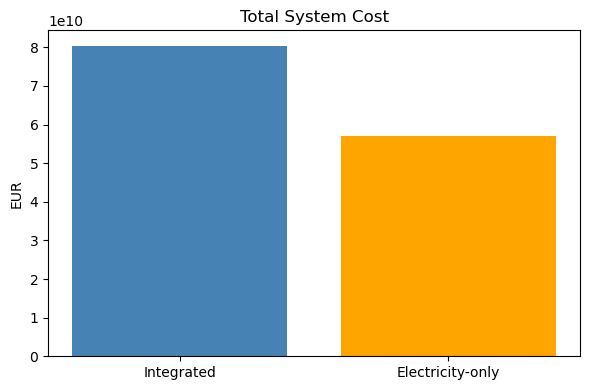

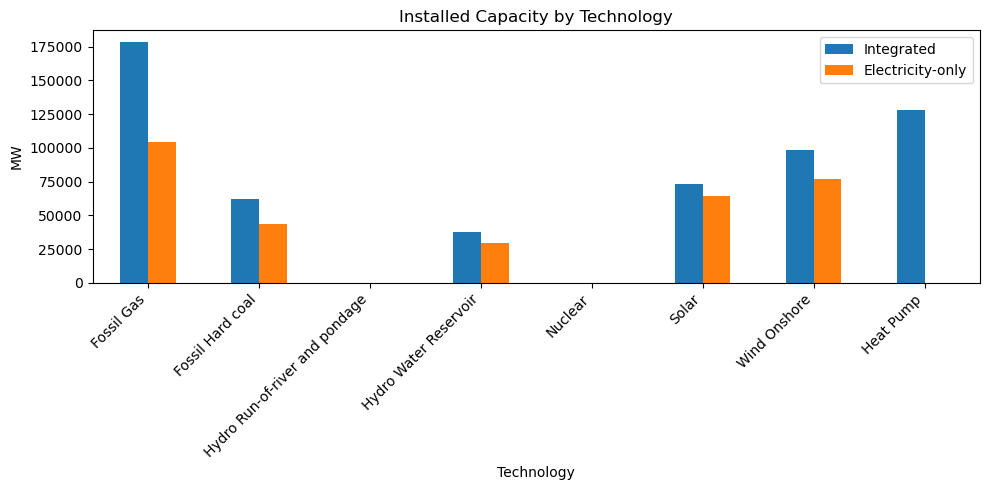

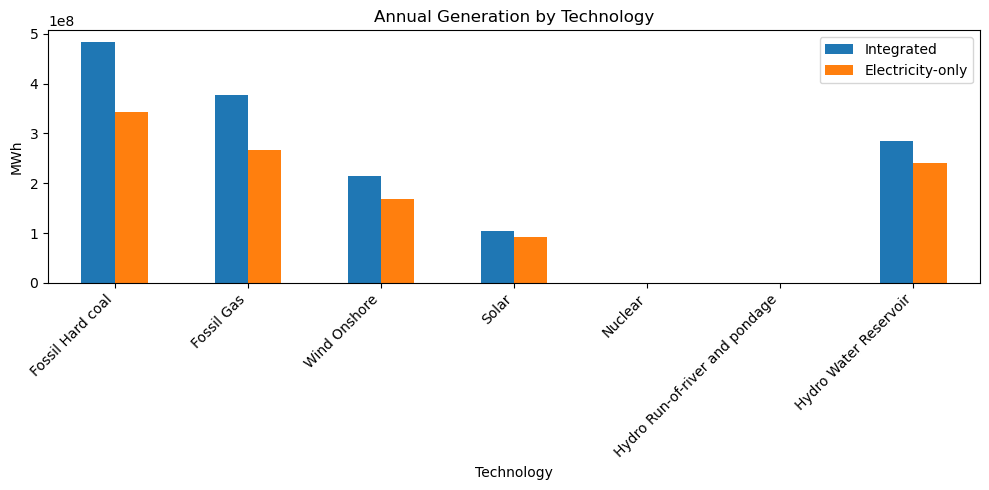


Results by country:
  Country  Electricity demand (MWh)  Heat demand (MWh)  \
0      DE              5.067493e+08       5.728044e+08   
1      FR              4.759524e+08       3.515356e+08   
2      AT              6.354977e+07       5.670465e+07   
3      CH              6.113596e+07       8.258350e+07   

   Electricity generation (MWh)  Heat pump capacity (MW)  
0                  5.769677e+08                 69323.00  
1                  5.981017e+08                 43447.33  
2                  1.016787e+08                  6168.33  
3                  1.851821e+08                  8961.98  


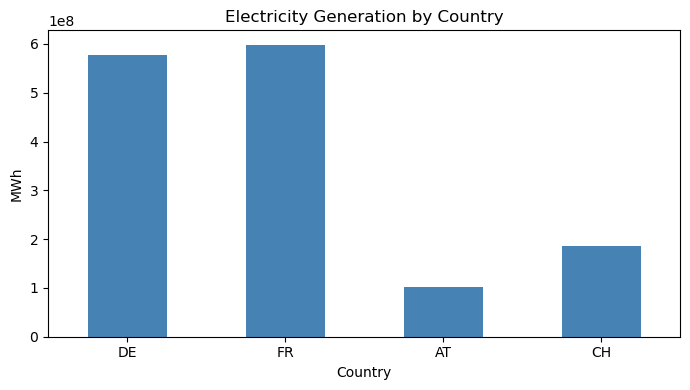

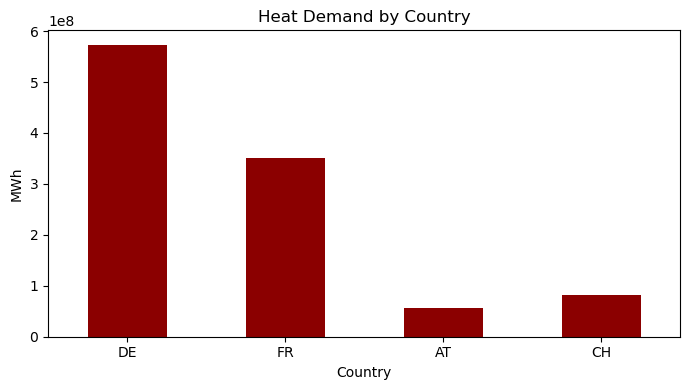

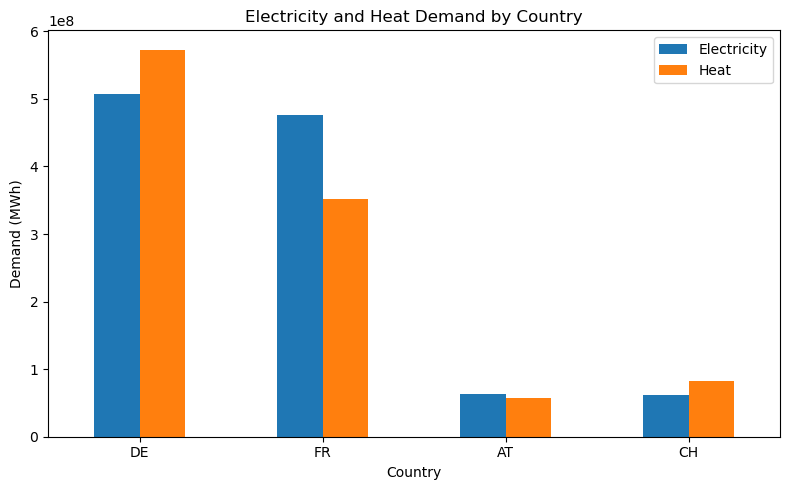


========== SIMPLE SUMMARY ==========
Integrated model total cost: 80,365,403,524.92 EUR
Electricity-only model total cost: 57,088,920,101.65 EUR
Total electricity demand in integrated model: 1,107,387,484.71 MWh
Total electricity demand in electricity-only model: 1,107,387,484.71 MWh
Total heat demand in integrated model: 1,063,628,106.27 MWh
Total installed heat pump capacity: 127,900.65 MW
The largest installed technology in the integrated model is Fossil Gas with 178,147.29 MW.
The technology producing the most electricity in the integrated model is Fossil Hard coal with 482,610,659.32 MWh.
The integrated model includes both electricity and heating.
This means electricity is also used for heat pumps to supply heat demand.
Comparing both scenarios shows how adding heating changes system cost, capacity expansion, and generation mix.

Plots saved in: c:\Users\Tessa Bruggeling\OneDrive - Danmarks Tekniske Universitet\master courses\Year 2\Integrated Energy Grids\Task I\Part D\results_s

In [24]:
# # ==========================================
# # Results extraction and visualization
# # ==========================================

# # Extract capacities
# cap_integrated = pd.concat([
#     n.generators.p_nom_opt.rename('p_nom_opt'),
#     n.links.p_nom_opt.rename('p_nom_opt')
# ])
# cap_elec = n_elec.generators.p_nom_opt.rename('p_nom_opt')

# # Prepare load data
# elec_load = n.loads_t.p_set.filter(regex='_elec_load$')
# heat_load = n.loads_t.p_set.filter(regex='_heat_load$')

# print("\n=== Capacity results (integrated) ===")
# print(cap_integrated.sort_values('p_nom_opt', ascending=False).head(20))

# print("\n=== Electricity-only capacity summary ===")
# print(cap_elec.sort_values('p_nom_opt', ascending=False).head(20))

# print("\n=== Total installed capacity comparison ===")
# print(f"Integrated total p_nom_opt: {cap_integrated['p_nom_opt'].sum():.1f} MW")
# print(f"Electricity-only total p_nom_opt: {cap_elec.sum():.1f} MW")
# print(f"Integrated heat pump capacity: {cap_integrated.filter(like='Heat Pump')['p_nom_opt'].sum():.1f} MWth")

# # Plot load profiles for one country
# country = 'DE'
# fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# if f"{country}_elec_load" in elec_load.columns:
#     ax[0].plot(n.snapshots, elec_load[f"{country}_elec_load"], label='Electricity demand', color='tab:blue')
#     ax[0].set_ylabel('Electricity demand (MW)')
#     ax[0].legend()
# else:
#     ax[0].text(0.5, 0.5, 'No electricity load data available', ha='center', va='center')

# if f"{country}_heat_load" in heat_load.columns:
#     ax[1].plot(n.snapshots, heat_load[f"{country}_heat_load"], label='Heat demand', color='tab:red')
#     ax[1].set_ylabel('Heat demand (MWth)')
#     ax[1].legend()
# else:
#     ax[1].text(0.5, 0.5, 'No heat load data available', ha='center', va='center')

# ax[1].set_xlabel('Time')
# fig.suptitle(f"Demand profiles for {country}")
# plt.tight_layout()
# plt.show()

# # Plot heat pump dispatch for the first week if available
# heat_dispatch = n.links_t.p0.filter(like='Heat Pump') if hasattr(n, 'links_t') else pd.DataFrame()
# if not heat_dispatch.empty:
#     sample = heat_dispatch.iloc[:168]
#     sample.plot(figsize=(14, 5))
#     plt.title('Heat pump dispatch (first week)')
#     plt.ylabel('Power (MW)')
#     plt.xlabel('Time')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("\n⚠️ No heat pump dispatch time series available for plotting.")

# # Plot installed capacity by carrier
# carrier_capacity = (
#     n.generators.reset_index()[['carrier', 'p_nom_opt']]
#     .groupby('carrier')['p_nom_opt']
#     .sum()
#     .sort_values(ascending=False)
# )

# fig, ax = plt.subplots(figsize=(12, 5))
# carrier_capacity.plot(kind='bar', ax=ax, color='tab:green')
# ax.set_ylabel('Installed capacity (MW)')
# ax.set_title('Installed generator capacity by carrier (integrated scenario)')
# ax.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

# print("\n✅ Results extraction and visualization complete.")

# ==========================================
# Simple results and plots
# ==========================================

print("\nCreating simple results...")

results_dir = os.path.join(script_dir, "results_simple")
os.makedirs(results_dir, exist_ok=True)

# ==========================================
# 1. Basic summary numbers
# ==========================================

# Total objective values
integrated_cost = n.objective
electricity_only_cost = n_elec.objective

# Total electricity demand
elec_loads_int = [f"{c}_elec_load" for c in countries if f"{c}_elec_load" in n.loads.index]
elec_loads_elec = [f"{c}_elec_load" for c in countries if f"{c}_elec_load" in n_elec.loads.index]

total_elec_demand_int = n.loads_t.p_set[elec_loads_int].sum().sum()
total_elec_demand_elec = n_elec.loads_t.p_set[elec_loads_elec].sum().sum()

# Total heat demand in integrated model
heat_loads_int = [f"{c}_heat_load" for c in countries if f"{c}_heat_load" in n.loads.index]
if len(heat_loads_int) > 0:
    total_heat_demand = n.loads_t.p_set[heat_loads_int].sum().sum()
else:
    total_heat_demand = 0

# Total heat pump capacity
heat_pumps = [f"{c}_Heat Pump" for c in countries if f"{c}_Heat Pump" in n.links.index]
if len(heat_pumps) > 0:
    total_hp_capacity = n.links.loc[heat_pumps, "p_nom_opt"].sum()
else:
    total_hp_capacity = 0

# ==========================================
# 2. Installed capacity by technology
# ==========================================

cap_int = n.generators.groupby("carrier")["p_nom_opt"].sum()
cap_elec = n_elec.generators.groupby("carrier")["p_nom_opt"].sum()

cap_compare = pd.concat(
    [cap_int.rename("Integrated"), cap_elec.rename("Electricity-only")],
    axis=1
).fillna(0)

# add heat pumps only to integrated case
cap_compare.loc["Heat Pump", "Integrated"] = total_hp_capacity
cap_compare = cap_compare.fillna(0)

print("\nInstalled capacities (MW):")
print(cap_compare.round(2))

# ==========================================
# 3. Annual generation by technology
# ==========================================

gen_int = {}
for tech in n.generators.carrier.unique():
    gens = n.generators.index[n.generators.carrier == tech]
    gen_int[tech] = n.generators_t.p[gens].sum().sum()

gen_elec = {}
for tech in n_elec.generators.carrier.unique():
    gens = n_elec.generators.index[n_elec.generators.carrier == tech]
    gen_elec[tech] = n_elec.generators_t.p[gens].sum().sum()

gen_compare = pd.concat(
    [pd.Series(gen_int, name="Integrated"),
     pd.Series(gen_elec, name="Electricity-only")],
    axis=1
).fillna(0)

print("\nAnnual generation (MWh):")
print(gen_compare.round(2))

# ==========================================
# 4. Plot 1: Total system cost comparison
# ==========================================

plt.figure(figsize=(6, 4))
plt.bar(["Integrated", "Electricity-only"],
        [integrated_cost, electricity_only_cost],
        color=["steelblue", "orange"])
plt.ylabel("EUR")
plt.title("Total System Cost")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "cost_comparison.png"), dpi=300)
plt.show()

# ==========================================
# 5. Plot 2: Installed capacity comparison
# ==========================================

cap_compare.plot(kind="bar", figsize=(10, 5))
plt.title("Installed Capacity by Technology")
plt.ylabel("MW")
plt.xlabel("Technology")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "capacity_comparison.png"), dpi=300)
plt.show()

# ==========================================
# 6. Plot 3: Annual generation comparison
# ==========================================

gen_compare.plot(kind="bar", figsize=(10, 5))
plt.title("Annual Generation by Technology")
plt.ylabel("MWh")
plt.xlabel("Technology")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "generation_comparison.png"), dpi=300)
plt.show()

# ==========================================
# 7. Simple results by country
# ==========================================

country_summary = []

for c in countries:
    # electricity demand
    elec_load_name = f"{c}_elec_load"
    elec_demand = n.loads_t.p_set[elec_load_name].sum() if elec_load_name in n.loads.index else 0

    # heat demand
    heat_load_name = f"{c}_heat_load"
    heat_demand = n.loads_t.p_set[heat_load_name].sum() if heat_load_name in n.loads.index else 0

    # electricity generation
    country_gens = [g for g in n.generators.index if g.startswith(f"{c}_")]
    if len(country_gens) > 0:
        generation = n.generators_t.p[country_gens].sum().sum()
    else:
        generation = 0

    # heat pump capacity
    hp_name = f"{c}_Heat Pump"
    hp_capacity = n.links.loc[hp_name, "p_nom_opt"] if hp_name in n.links.index else 0

    country_summary.append({
        "Country": c,
        "Electricity demand (MWh)": elec_demand,
        "Heat demand (MWh)": heat_demand,
        "Electricity generation (MWh)": generation,
        "Heat pump capacity (MW)": hp_capacity
    })

country_summary_df = pd.DataFrame(country_summary)

print("\nResults by country:")
print(country_summary_df.round(2))

country_summary_df.to_csv(os.path.join(results_dir, "country_summary.csv"), index=False)

# Plot 4: Electricity generation by country
country_summary_df.plot(
    x="Country",
    y="Electricity generation (MWh)",
    kind="bar",
    legend=False,
    figsize=(7, 4),
    color="steelblue"
)
plt.title("Electricity Generation by Country")
plt.ylabel("MWh")
plt.xlabel("Country")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "generation_by_country.png"), dpi=300)
plt.show()

country_summary_df.plot(
    x="Country",
    y="Heat demand (MWh)",
    kind="bar",
    legend=False,
    figsize=(7, 4),
    color="darkred"
)
plt.title("Heat Demand by Country")
plt.ylabel("MWh")
plt.xlabel("Country")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "heat_demand_by_country.png"), dpi=300)
plt.show()

# ==========================================
# Plot: Electricity and Heat Demand by Country
# ==========================================

country_summary_df.plot(
    x="Country",
    y=["Electricity demand (MWh)", "Heat demand (MWh)"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Electricity and Heat Demand by Country")
plt.ylabel("Demand (MWh)")
plt.xlabel("Country")
plt.xticks(rotation=0)
plt.legend(["Electricity", "Heat"])
plt.tight_layout()

plt.savefig(os.path.join(results_dir, "country_demand_comparison.png"), dpi=300)
plt.show()


# ==========================================
# 7. Simple written summary
# ==========================================

print("\n========== SIMPLE SUMMARY ==========")
print(f"Integrated model total cost: {integrated_cost:,.2f} EUR")
print(f"Electricity-only model total cost: {electricity_only_cost:,.2f} EUR")
print(f"Total electricity demand in integrated model: {total_elec_demand_int:,.2f} MWh")
print(f"Total electricity demand in electricity-only model: {total_elec_demand_elec:,.2f} MWh")
print(f"Total heat demand in integrated model: {total_heat_demand:,.2f} MWh")
print(f"Total installed heat pump capacity: {total_hp_capacity:,.2f} MW")

# Most important technology
if not cap_compare["Integrated"].empty:
    biggest_capacity = cap_compare["Integrated"].sort_values(ascending=False)
    print(f"The largest installed technology in the integrated model is {biggest_capacity.index[0]} "
          f"with {biggest_capacity.iloc[0]:,.2f} MW.")

if not gen_compare["Integrated"].empty:
    biggest_generation = gen_compare["Integrated"].sort_values(ascending=False)
    print(f"The technology producing the most electricity in the integrated model is {biggest_generation.index[0]} "
          f"with {biggest_generation.iloc[0]:,.2f} MWh.")

print("The integrated model includes both electricity and heating.")
print("This means electricity is also used for heat pumps to supply heat demand.")
print("Comparing both scenarios shows how adding heating changes system cost, capacity expansion, and generation mix.")

print(f"\nPlots saved in: {results_dir}")